# End-to-End Credit Risk Optimization: Underwriting, Affordability, and Collections

**Objective:** To restructure the credit lifecycle of a hypothetical consumer lending portfolio. This project moves from raw data simulation to active policy development, focusing on minimizing expected losses and mathematically validating operational strategies.

**Environment:** Python 3.11.4 (Anaconda)
**Core Libraries:** `pandas`, `numpy`, `uuid`, `matplotlib`, `seaborn`, `scipy`

---

*I have the libraries installed already, so I won't be installing them. Run the code below to install all the needed libraries.*

`%pip install pandas numpy matplotlib seaborn scipy`

## 1. Synthetic Data Engineering
Proprietary financial data is highly restricted. To build a realistic portfolio, this script generates a 10,000-row synthetic dataset using `numpy` for high-performance vectorized operations, avoiding slow `for` loops.

**Code Breakdown:**
* **`np.random.lognormal`**: Generates a right-skewed income distribution typical of real-world wages.
* **`np.clip`**: Enforces logical boundaries on the data (e.g., ensuring DTI stays within 1% to 60%, and ages don't fall below 18).
* **`np.where`**: Acts as a vectorized IF/THEN statement to engineer complex risk factors, ensuring that high DTI and maxed-out utilization programmatically force higher default rates in the `loan_status` column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import uuid

In [2]:
df = pd.read_csv('credit_risk_portfolio.csv')
print(df.head())

                            customer_id  age  employment_length_yrs  \
0  ca7f4434-ddde-4f34-8e24-44a77b4fada5   56                     29   
1  f8fcb379-2d85-48db-a995-48d1ed51aa58   69                     40   
2  b2a71e8e-815e-4971-8e3b-363f6a0a855b   46                     22   
3  bc9d11be-fbeb-43fd-9813-f699f5521df3   32                     10   
4  6b5cf4f0-ed47-4cf7-9edb-60cbb6a0d572   60                     40   

   annual_income  credit_score  dti_ratio  num_open_accounts  \
0       43168.44           581       0.36                 20   
1       64742.08           658       0.35                  4   
2       67867.10           681       0.41                  4   
3       37696.59           573       0.24                  8   
4       71090.07           589       0.37                  4   

   utilization_rate  recent_delinquencies  \
0              0.67                     3   
1              0.41                     2   
2              0.35                     1   
3       

## 2. Exploratory Data Analysis (EDA)
Before writing new credit policies, we use `pandas`, `matplotlib`, and `seaborn` to establish a factual baseline of the portfolio’s structural health and visually isolate the strongest predictors of risk.

**Code Breakdown:**
* **Target Distribution**: `value_counts(normalize=True)` calculates the exact percentage breakdown of the portfolio's health.
* **Categorical Risk**: `df.groupby('loan_purpose')['is_default'].mean()` isolates the average default rate by segment, visualized via `sns.barplot`.
* **Continuous Risk Drivers**: We use `sns.histplot` and `sns.boxplot` to visualize the overlapping density curves of Credit Score, DTI, and Utilization, proving mathematically how these variables drive defaults.
* **Multicollinearity Check**: `df.corr()` generates a correlation matrix, masked and visualized via `sns.heatmap` to validate the inverse relationship between credit scores and interest rates.

In [3]:
# Set visualization style
sns.set_theme(style="whitegrid")

In [4]:
print("\nData Types and Missing Values:")
display(df.info())


Data Types and Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            10000 non-null  str    
 1   age                    10000 non-null  int64  
 2   employment_length_yrs  10000 non-null  int64  
 3   annual_income          10000 non-null  float64
 4   credit_score           10000 non-null  int64  
 5   dti_ratio              10000 non-null  float64
 6   num_open_accounts      10000 non-null  int64  
 7   utilization_rate       10000 non-null  float64
 8   recent_delinquencies   10000 non-null  int64  
 9   loan_id                10000 non-null  str    
 10  loan_amount            10000 non-null  float64
 11  interest_rate          10000 non-null  float64
 12  loan_term_months       10000 non-null  int64  
 13  loan_purpose           10000 non-null  str    
 14  loan_status            10000 non-n

None

In [5]:
# 6. Macro Summary Statistics
print("\n--- SUMMARY STATISTICS ---")
display(df.describe().round(2))


--- SUMMARY STATISTICS ---


,age,employment_length_yrs,annual_income,credit_score,dti_ratio,num_open_accounts,utilization_rate,recent_delinquencies,loan_amount,interest_rate,loan_term_months,days_past_due,total_principal_paid,total_interest_paid
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,48.8,24.05,68450.16,601.61,0.30,12.48,0.50,1.88,19807.84,0.19,32.59,91.57,10199.32,3746.40
std,17.9,14.54,37924.72,65.16,0.10,6.89,0.20,1.43,12367.17,0.04,17.69,140.35,9776.42,4527.54
min,18.0,0.00,20000.00,396.00,0.01,1.00,0.00,0.00,2008.18,0.05,12.00,0.00,0.72,0.48
25%,34.0,11.00,41667.64,557.00,0.23,7.00,0.36,1.00,10311.65,0.17,12.00,3.00,3272.54,918.80
50%,49.0,26.00,59461.88,597.00,0.30,12.00,0.50,2.00,16540.59,0.19,24.00,19.00,6975.60,2169.39
75%,64.0,40.00,85499.77,642.00,0.37,18.00,0.64,3.00,26490.43,0.22,36.00,118.00,13874.87,4774.34
max,79.0,40.00,250000.00,850.00,0.60,24.00,1.00,4.00,50000.00,0.31,60.00,499.00,50000.00,42383.94


C:\Users\USER\AppData\Local\Temp\ipykernel_10036\2544224844.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')


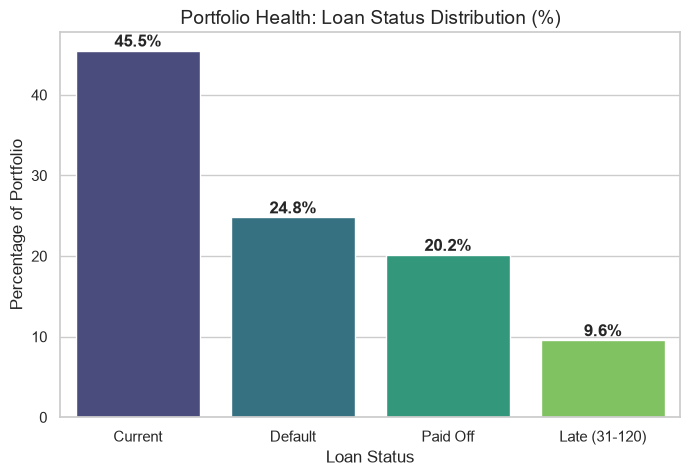

In [7]:
# 7. Portfolio Health (Target Variable Distribution)
plt.figure(figsize=(8, 5))
status_counts = df['loan_status'].value_counts(normalize=True) * 100
sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')
plt.title('Portfolio Health: Loan Status Distribution (%)', fontsize=14)
plt.ylabel('Percentage of Portfolio')
plt.xlabel('Loan Status')
for i, v in enumerate(status_counts.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

# Create a binary 'is_default' flag for risk analysis (Default + Late = 1, Current + Paid Off = 0)
df['is_default'] = np.where(df['loan_status'].isin(['Default', 'Late (31-120)']), 1, 0)

C:\Users\USER\AppData\Local\Temp\ipykernel_10036\3251607513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_risk.index, y=purpose_risk.values, palette='mako')


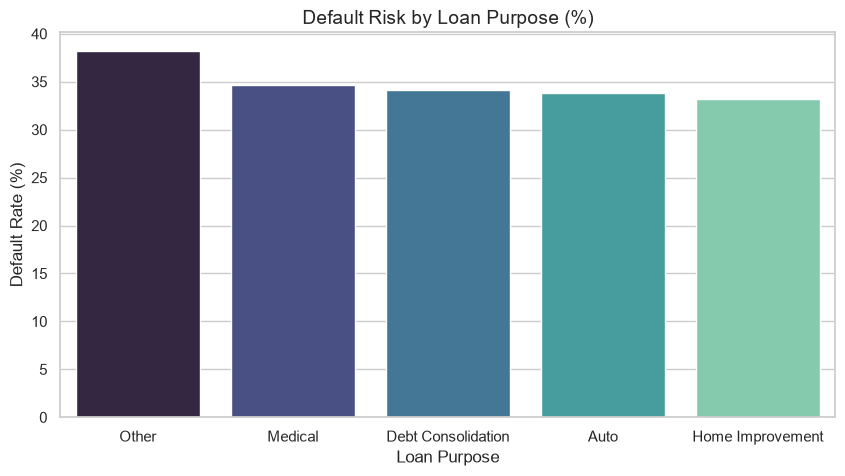

In [8]:
# 8. Risk Segmentation: Default Rate by Loan Purpose
plt.figure(figsize=(10, 5))
purpose_risk = df.groupby('loan_purpose')['is_default'].mean().sort_values(ascending=False) * 100
sns.barplot(x=purpose_risk.index, y=purpose_risk.values, palette='mako')
plt.title('Default Risk by Loan Purpose (%)', fontsize=14)
plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Purpose')
plt.show()

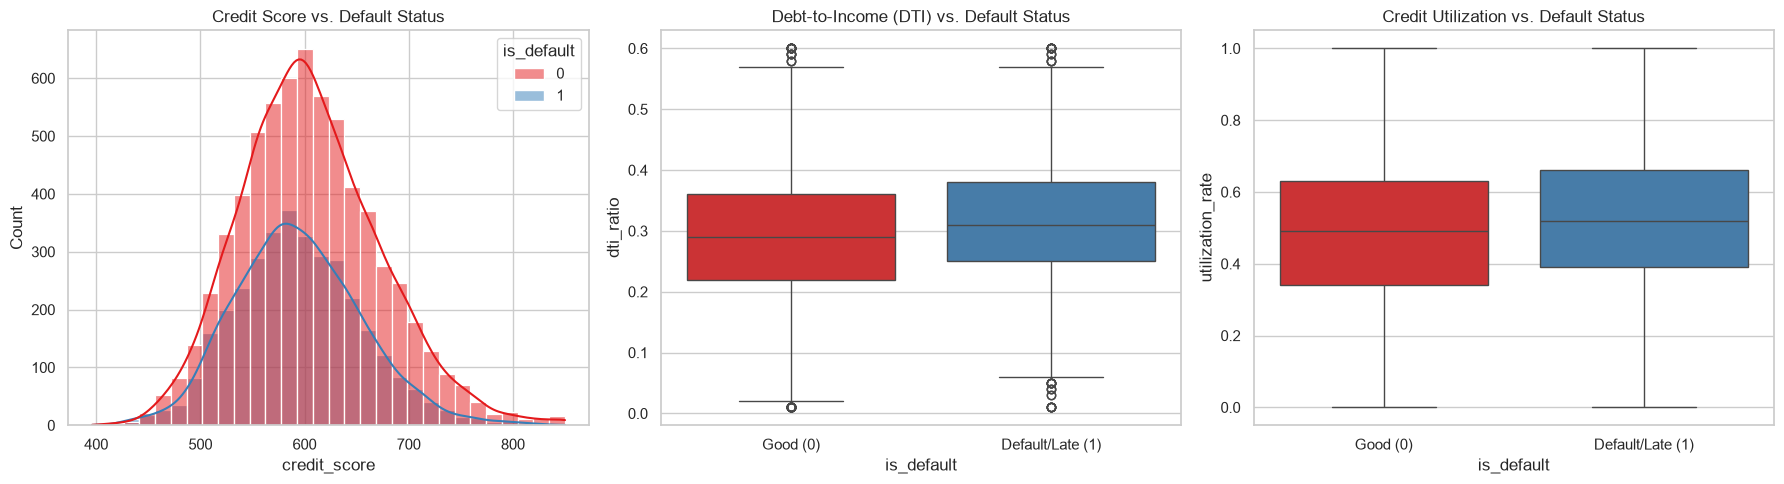

In [9]:
# 9. Continuous Risk Drivers (Credit Score, Income, DTI)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Credit Score Distribution by Default Status
sns.histplot(data=df, x='credit_score', hue='is_default', kde=True, ax=axes[0], palette='Set1', bins=30)
axes[0].set_title('Credit Score vs. Default Status')

# DTI Ratio by Default Status
sns.boxplot(data=df, x='is_default', y='dti_ratio', hue='is_default', legend=False, ax=axes[1], palette='Set1')
axes[1].set_title('Debt-to-Income (DTI) vs. Default Status')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Good (0)', 'Default/Late (1)'])

# Utilization Rate by Default Status
sns.boxplot(data=df, x='is_default', y='utilization_rate', hue='is_default', legend=False, ax=axes[2], palette='Set1')
axes[2].set_title('Credit Utilization vs. Default Status')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Good (0)', 'Default/Late (1)'])

plt.tight_layout()
plt.show()

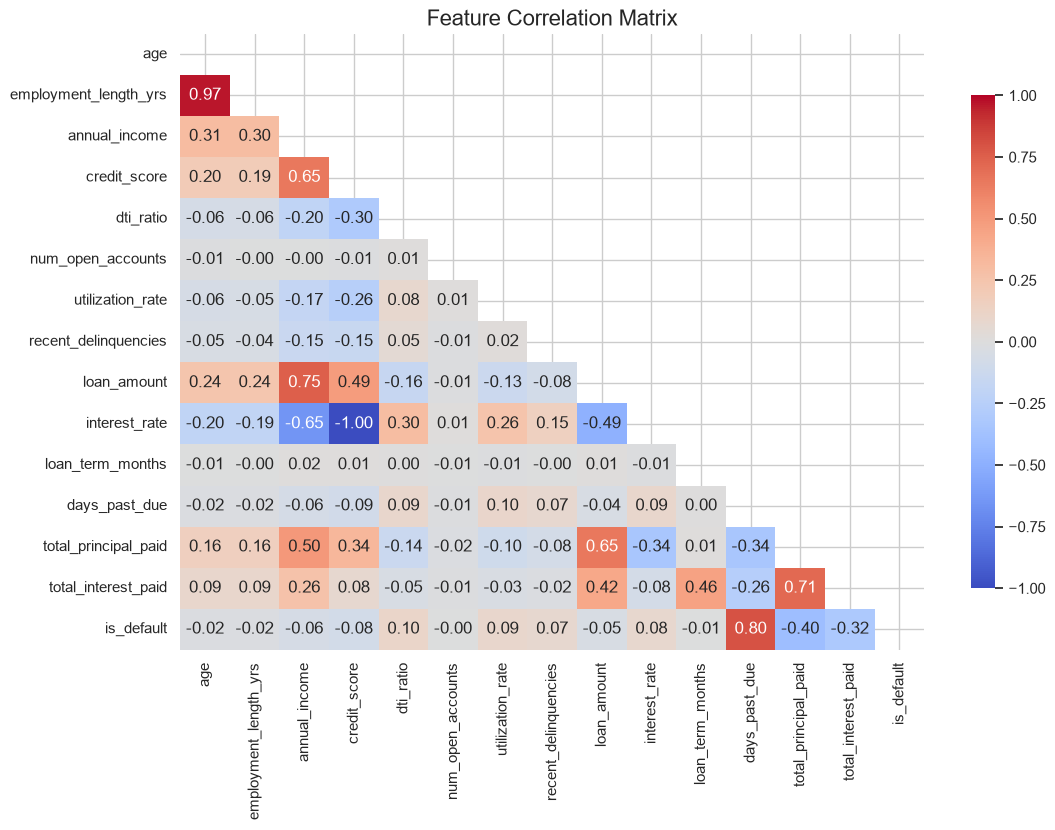

In [10]:
# 10. Correlation Heatmap (Multicollinearity Check)
plt.figure(figsize=(12, 8))
# Select only numerical columns for correlation
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

# Mask the upper triangle for cleaner visualization
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

## 3. Score Cut-off Optimisation
A score cut-off analysis balances risk and reward. This script calculates the Net Profit for every loan, simulates the portfolio at various minimum credit score requirements, and plots the resulting profit curve.

**Code Breakdown:**
* **Iteration & Subsetting**: A `for` loop iterates through score thresholds (500 to 750). At each step, `df[df['credit_score'] >= cutoff]` subsets the dataframe to simulate the approved portfolio.
* **Optimization Extraction**: `results_df['Total_Profit'].idxmax()` programmatically finds the exact index of the peak profit, allowing us to extract the optimal credit score automatically.
* **Dual-Axis Visualization**: `ax.twinx()` generates a secondary Y-axis in `matplotlib`, allowing us to overlay the continuous Profit Curve (dollars) against the Approval and Default Rates (percentages) on the same chart.

In [11]:
# 1. Define the financial metrics.
# Create binary default flag
df['is_default'] = np.where(df['loan_status'].isin(['Default', 'Late (31-120)']), 1, 0)

# Calculate Net Profit per loan: (Principal Collected + Interest Collected) - Original Loan Amount disbursed
df['net_profit'] = (df['total_principal_paid'] + df['total_interest_paid']) - df['loan_amount']


In [12]:
# 2. Simulate portfolio performance across different cut-offs
cutoffs = range(500, 751, 5)
results = []

for cutoff in cutoffs:
    # Filter for loans that would be approved at this threshold
    approved_portfolio = df[df['credit_score'] >= cutoff]
    
    if len(approved_portfolio) == 0:
        continue
        
    approval_rate = len(approved_portfolio) / len(df) * 100
    default_rate = approved_portfolio['is_default'].mean() * 100
    total_profit = approved_portfolio['net_profit'].sum()
    
    results.append({
        'Cutoff': cutoff,
        'Approval_Rate_Pct': approval_rate,
        'Default_Rate_Pct': default_rate,
        'Total_Profit': total_profit
    })

results_df = pd.DataFrame(results)

In [13]:
# 3. Identify the optimal cut-off (Peak Profit)
optimal_idx = results_df['Total_Profit'].idxmax()
optimal_cutoff = results_df.loc[optimal_idx, 'Cutoff']
max_profit = results_df.loc[optimal_idx, 'Total_Profit']

print(f"--- SCORE CUT-OFF ANALYSIS RESULTS ---")
print(f"Optimal Credit Score Cut-off: {optimal_cutoff}")
print(f"Maximum Expected Portfolio Profit: ${max_profit:,.2f}")
print(f"Approval Rate at this Cut-off: {results_df.loc[optimal_idx, 'Approval_Rate_Pct']:.1f}%")
print(f"Default Rate at this Cut-off: {results_df.loc[optimal_idx, 'Default_Rate_Pct']:.1f}%\n")

--- SCORE CUT-OFF ANALYSIS RESULTS ---
Optimal Credit Score Cut-off: 750
Maximum Expected Portfolio Profit: $-3,342,696.45
Approval Rate at this Cut-off: 2.1%
Default Rate at this Cut-off: 19.5%



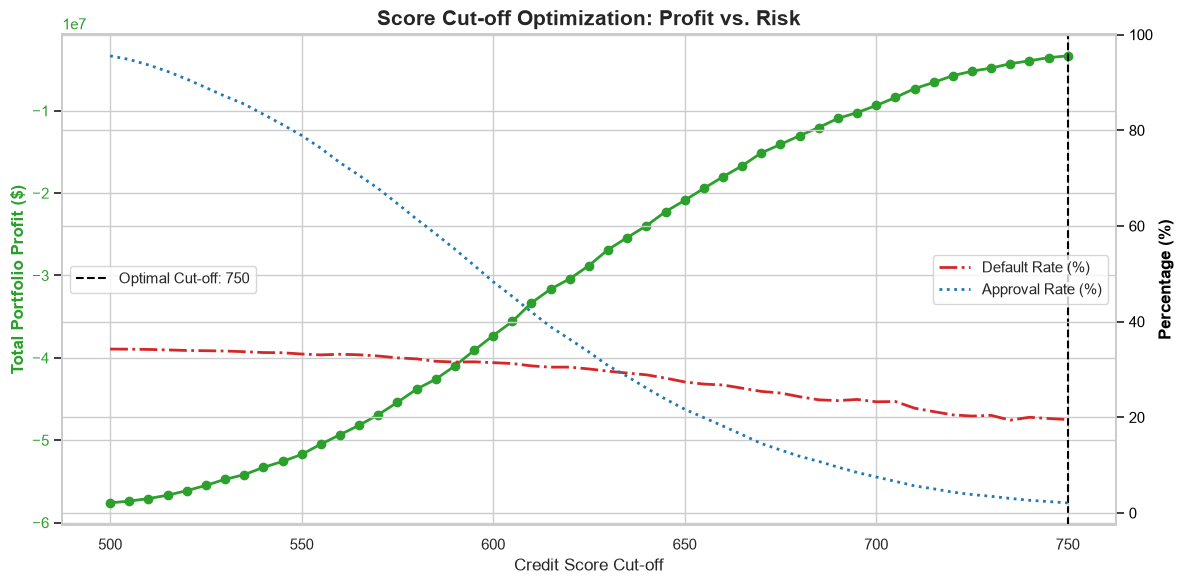

In [14]:
# 4. Visualize the Profit Curve against Risk and Approval Rates
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Profit on the primary y-axis
color = 'tab:green'
ax1.set_xlabel('Credit Score Cut-off')
ax1.set_ylabel('Total Portfolio Profit ($)', color=color, fontweight='bold')
ax1.plot(results_df['Cutoff'], results_df['Total_Profit'], color=color, linewidth=2, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(x=optimal_cutoff, color='black', linestyle='--', label=f'Optimal Cut-off: {optimal_cutoff}')
ax1.legend(loc='center left')

# Create a secondary y-axis for Default and Approval Rates
ax2 = ax1.twinx()  
color2 = 'tab:red'
color3 = 'tab:blue'
ax2.set_ylabel('Percentage (%)', color='black', fontweight='bold')  
ax2.plot(results_df['Cutoff'], results_df['Default_Rate_Pct'], color=color2, linestyle='-.', linewidth=2, label='Default Rate (%)')
ax2.plot(results_df['Cutoff'], results_df['Approval_Rate_Pct'], color=color3, linestyle=':', linewidth=2, label='Approval Rate (%)')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='center right')

plt.title('Score Cut-off Optimization: Profit vs. Risk', fontsize=15, fontweight='bold')
fig.tight_layout()  
plt.show()

## 4. Affordability & Rule-Based Decision Engine
With the optimal credit score identified, we build a vectorized rule-based engine to dynamically adjust credit limits and forecast portfolio profitability. 

**Code Breakdown:**
* **Column-wise Operations**: `df['monthly_income'] * MAX_DTI` calculates raw affordability capacity directly across the entire dataframe.
* **Hard Policy Constraints**: `df[['calculated_limit', 'policy_cap']].min(axis=1)` compares two columns and assigns the lowest value, enforcing our 20% max-income rule. 
* **The Decision Engine**: `np.where()` evaluates three simultaneous conditions (score > cut-off, limit > minimum, no recent delinquencies) to generate an 'Approved' or 'Declined' flag.
* **Expected Loss (EL)**: Calculates forecasted losses using the standard `Limit * PD * LGD` formula to output a final simulated Net Profit.

In [15]:
# ==========================================
# PHASE 1: AFFORDABILITY & LIMIT ASSIGNMENT
# ==========================================
# Policy Parameters
MAX_DTI = 0.45                  # Maximum allowable DTI (existing + new debt)
MAX_LIMIT_PCT_INCOME = 0.20     # Loan cannot exceed 20% of annual income
ABSOLUTE_MAX_LIMIT = 50000      # Hard cap on any single loan
MIN_CREDIT_SCORE = 640          # Assume 640 was our optimal cut-off from the previous analysis

# 1. Calculate existing monthly debt burden
df['monthly_income'] = df['annual_income'] / 12
df['existing_monthly_debt'] = df['monthly_income'] * df['dti_ratio']

# 2. Affordability: How much new monthly payment can they afford before hitting 45% DTI?
df['available_payment_capacity'] = (df['monthly_income'] * MAX_DTI) - df['existing_monthly_debt']
df['available_payment_capacity'] = np.clip(df['available_payment_capacity'], 0, None) # No negative capacity

# 3. Translate payment capacity into a Maximum Loan Limit 
# Rule of thumb: Affordability capacity * 30 approximates a 36-month term limit
df['calculated_limit'] = df['available_payment_capacity'] * 30

# 4. Apply hard policy constraints to the limit
df['policy_cap'] = df['annual_income'] * MAX_LIMIT_PCT_INCOME
# Final limit is the lowest of the calculated limit, the policy cap, or the absolute max
df['final_assigned_limit'] = df[['calculated_limit', 'policy_cap']].min(axis=1)
df['final_assigned_limit'] = np.clip(df['final_assigned_limit'], 0, ABSOLUTE_MAX_LIMIT)

In [16]:
# ==========================================
# PHASE 2: RULE-BASED DECISION ENGINE
# ==========================================
# Approve only if they meet the score cut-off, have room in their DTI, and have NO recent delinquencies
df['policy_decision'] = np.where(
    (df['credit_score'] >= MIN_CREDIT_SCORE) & 
    (df['final_assigned_limit'] > 1000) &  # Must qualify for at least $1k
    (df['recent_delinquencies'] == 0), 
    'Approved', 
    'Declined'
)

In [17]:
# ==========================================
# PHASE 3: P&L FORECASTING 
# ==========================================
# Isolate the newly approved portfolio
approved_df = df[df['policy_decision'] == 'Approved'].copy()

# 1. Expected Revenue (Annualized)
# simplified as: Assigned Limit * Interest Rate
approved_df['expected_annual_interest'] = approved_df['final_assigned_limit'] * approved_df['interest_rate']

# 2. Expected Loss (EL)
# Assign a forecasted Probability of Default (PD) based on credit bands
approved_df['forecast_pd'] = np.where(approved_df['credit_score'] > 750, 0.02,
                             np.where(approved_df['credit_score'] > 700, 0.05,
                             np.where(approved_df['credit_score'] > 650, 0.10, 0.15)))

# Assume Loss Given Default (LGD) is 75% (we recover 25% through collections)
LGD = 0.75
# EL = Exposure (Limit) * PD * LGD
approved_df['expected_loss'] = approved_df['final_assigned_limit'] * approved_df['forecast_pd'] * LGD

# 3. Net Forecast
approved_df['forecasted_net_profit'] = approved_df['expected_annual_interest'] - approved_df['expected_loss']

# Output Strategic Summary
print("--- STRATEGIC POLICY & P&L SUMMARY ---")
print(f"Total Applications Processed: {len(df):,}")
print(f"Total Approved: {len(approved_df):,} ({(len(approved_df)/len(df))*100:.1f}%)")
print(f"Total Credit Exposure (Limits Assigned): ${approved_df['final_assigned_limit'].sum():,.2f}")
print("-" * 40)
print(f"Expected Annual Interest Revenue:  ${approved_df['expected_annual_interest'].sum():,.2f}")
print(f"Expected Annual Credit Losses:    -${approved_df['expected_loss'].sum():,.2f}")
print(f"Forecasted Net Profit:             ${approved_df['forecasted_net_profit'].sum():,.2f}")

--- STRATEGIC POLICY & P&L SUMMARY ---
Total Applications Processed: 10,000
Total Approved: 719 (7.2%)
Total Credit Exposure (Limits Assigned): $15,292,329.07
----------------------------------------
Expected Annual Interest Revenue:  $1,929,198.61
Expected Annual Credit Losses:    -$772,836.39
Forecasted Net Profit:             $1,156,362.22


## 5. Collections Strategy A/B Testing
To optimise the back-end of the credit lifecycle, we evaluate a simulated A/B test targeting the "Late (31-120 days)" segment using the `scipy.stats` module.

**Code Breakdown:**
* **Segment Isolation**: `df[df['loan_status'] == 'Late (31-120)']` slices the dataframe to only include the target population.
* **Metric Calculation**: Calculates the `recovery_rate` (principal paid divided by loan amount) as our primary success metric.
* **Statistical Testing**: `stats.ttest_ind(treatment, control, equal_var=False)` executes a two-sample independent T-test with Welch's correction to handle potentially unequal variances between groups.
* **Automated Decisioning**: An `if p_value < 0.05` logic block automatically evaluates the alpha threshold to declare whether the new SMS strategy is a statistically significant winner.

In [18]:
from scipy import stats

In [19]:
# 1. Isolate the target collections segment
collections_df = df[df['loan_status'] == 'Late (31-120)'].copy()

# Define the success metric: Recovery Rate (Principal paid / Total Loan Amount)
collections_df['recovery_rate'] = collections_df['total_principal_paid'] / collections_df['loan_amount']

# 2. Split the data by the experimental groups
control_group = collections_df[collections_df['test_group'] == 'Control']['recovery_rate']
treatment_group = collections_df[collections_df['test_group'] == 'Treatment']['recovery_rate']

# 3. Statistical Testing (Independent T-Test with Welch's correction)
# Used to compare the means of two independent groups with potentially unequal variances.
t_stat, p_value = stats.ttest_ind(treatment_group, control_group, equal_var=False)

# 4. Output A/B Test Results
print("--- COLLECTIONS A/B TEST RESULTS ---")
print(f"Segment Analyzed: Late (31-120) Days Past Due")
print(f"Control Group Size: N = {len(control_group)}")
print(f"Treatment Group Size: N = {len(treatment_group)}\n")

print(f"Control Average Recovery Rate: {control_group.mean() * 100:.2f}%")
print(f"Treatment Average Recovery Rate: {treatment_group.mean() * 100:.2f}%\n")

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}\n")

# Business Logic: Alpha = 0.05 (95% Confidence)
if p_value < 0.05:
    if treatment_group.mean() > control_group.mean():
        print("CONCLUSION: Validated. The Treatment strategy significantly improved recovery rates.")
    else:
        print("CONCLUSION: The Treatment strategy performed significantly worse than Control.")
else:
    print("CONCLUSION: Inconclusive. No statistically significant difference between strategies.")

--- COLLECTIONS A/B TEST RESULTS ---
Segment Analyzed: Late (31-120) Days Past Due
Control Group Size: N = 471
Treatment Group Size: N = 485

Control Average Recovery Rate: 23.84%
Treatment Average Recovery Rate: 25.12%

T-Statistic: 1.3647
P-Value: 0.172661

CONCLUSION: Inconclusive. No statistically significant difference between strategies.
